# Lab 2

Finish a function in `lab2.py`, then run its cell.

In [4]:
%load_ext autoreload
%autoreload 2
from viz import explore, draw_vacuum, draw_blocks, draw_cloud, workshop_problem

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Matplotlib is building the font cache; this may take a moment.


## The given part: text to tree

In [12]:
from lab2 import *

parse_tree(tokenize("(:action suck :parameters (?c - cell) :effect (and (clean ?c) (not (dirty ?c))))"))

[':action',
 'suck',
 ':parameters',
 ['?c', '-', 'cell'],
 ':effect',
 ['and', ['clean', '?c'], ['not', ['dirty', '?c']]]]

## Your part: tree to Problem, Domain

In [10]:
problem = parse_problem(open("vacuum-tiny.pddl").read())
# problem.objects, problem.goal
vars(problem)

{'name': 'tiny',
 'domain': 'vacuum',
 'objects': {'c11': 'cell',
  'c12': 'cell',
  'c13': 'cell',
  'c21': 'cell',
  'c22': 'cell',
  'c23': 'cell'},
 'init': frozenset({('adjacent', 'c11', 'c12'),
            ('adjacent', 'c11', 'c21'),
            ('adjacent', 'c12', 'c11'),
            ('adjacent', 'c12', 'c13'),
            ('adjacent', 'c12', 'c22'),
            ('adjacent', 'c13', 'c12'),
            ('adjacent', 'c13', 'c23'),
            ('adjacent', 'c21', 'c11'),
            ('adjacent', 'c21', 'c22'),
            ('adjacent', 'c22', 'c12'),
            ('adjacent', 'c22', 'c21'),
            ('adjacent', 'c22', 'c23'),
            ('adjacent', 'c23', 'c13'),
            ('adjacent', 'c23', 'c22'),
            ('clean', 'c11'),
            ('clean', 'c13'),
            ('clean', 'c21'),
            ('clean', 'c22'),
            ('dirty', 'c12'),
            ('dirty', 'c23'),
            ('robot-at', 'c11')}),
 'goal': frozenset({('clean', 'c11'),
            ('clean', 'c12'

In [13]:
domain = parse_domain(open("vacuum-domain.pddl").read())

domain.actions["suck"]
print(domain)

Domain(name='vacuum', types={'cell': 'object'}, predicates={'robot-at': (('?c', 'cell'),), 'dirty': (('?c', 'cell'),), 'clean': (('?c', 'cell'),), 'adjacent': (('?a', 'cell'), ('?b', 'cell'))}, actions={'move': Action(name='move', params=(('?from', 'cell'), ('?to', 'cell')), pre=frozenset({('robot-at', '?from'), ('adjacent', '?from', '?to')}), add=frozenset({('robot-at', '?to')}), delete=frozenset({('robot-at', '?from')})), 'suck': Action(name='suck', params=(('?c', 'cell'),), pre=frozenset({('dirty', '?c'), ('robot-at', '?c')}), add=frozenset({('clean', '?c')}), delete=frozenset({('dirty', '?c')}))})


## Last week's world, as a graph

In [14]:
domain, problem, actions = load("vacuum-domain.pddl", "vacuum-tiny.pddl")
print(len(actions), "grounded actions")
# print(successors(problem.init, actions))
for name in successors(problem.init, actions):
    print(name)

42 grounded actions
move(c11, c12)
move(c11, c21)


24 states, 60 transitions


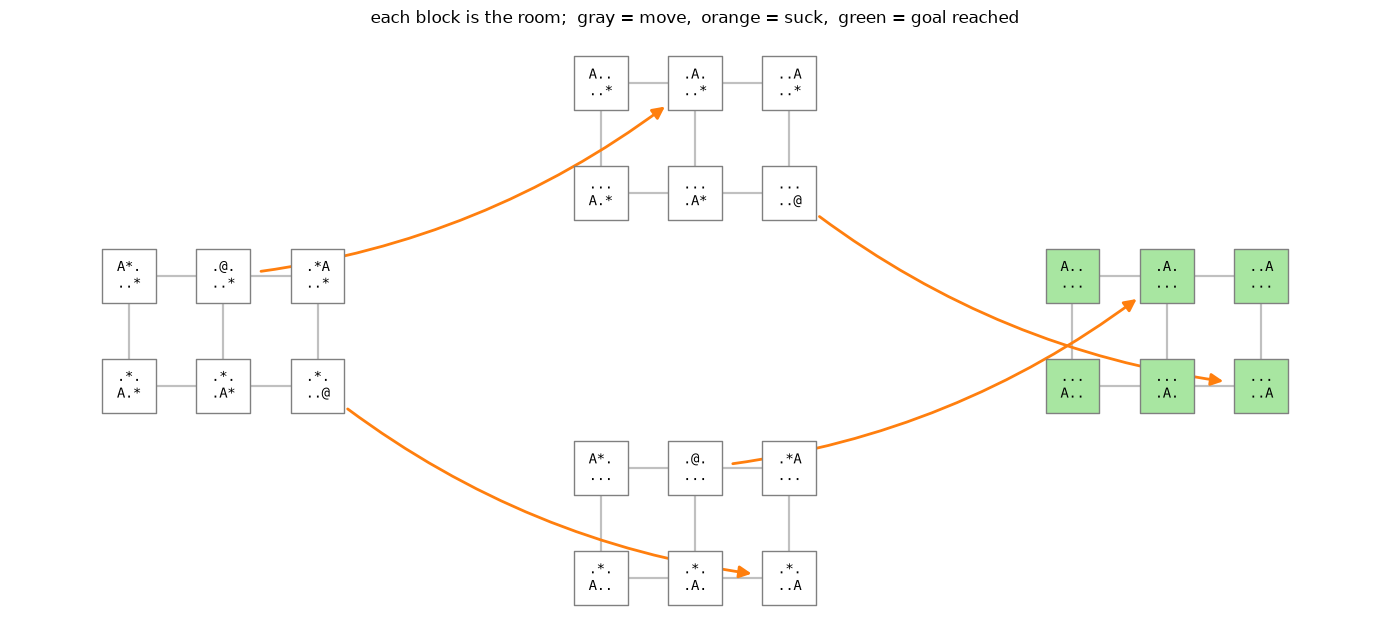

In [15]:
G = explore(problem.init, actions)
print(G.number_of_nodes(), "states,", G.number_of_edges(), "transitions")
draw_vacuum(G, problem.goal)

Same 24 states as Lab 1. The rules were Python then; now they are a file your code reads.

## Blocks

22 states, 42 transitions


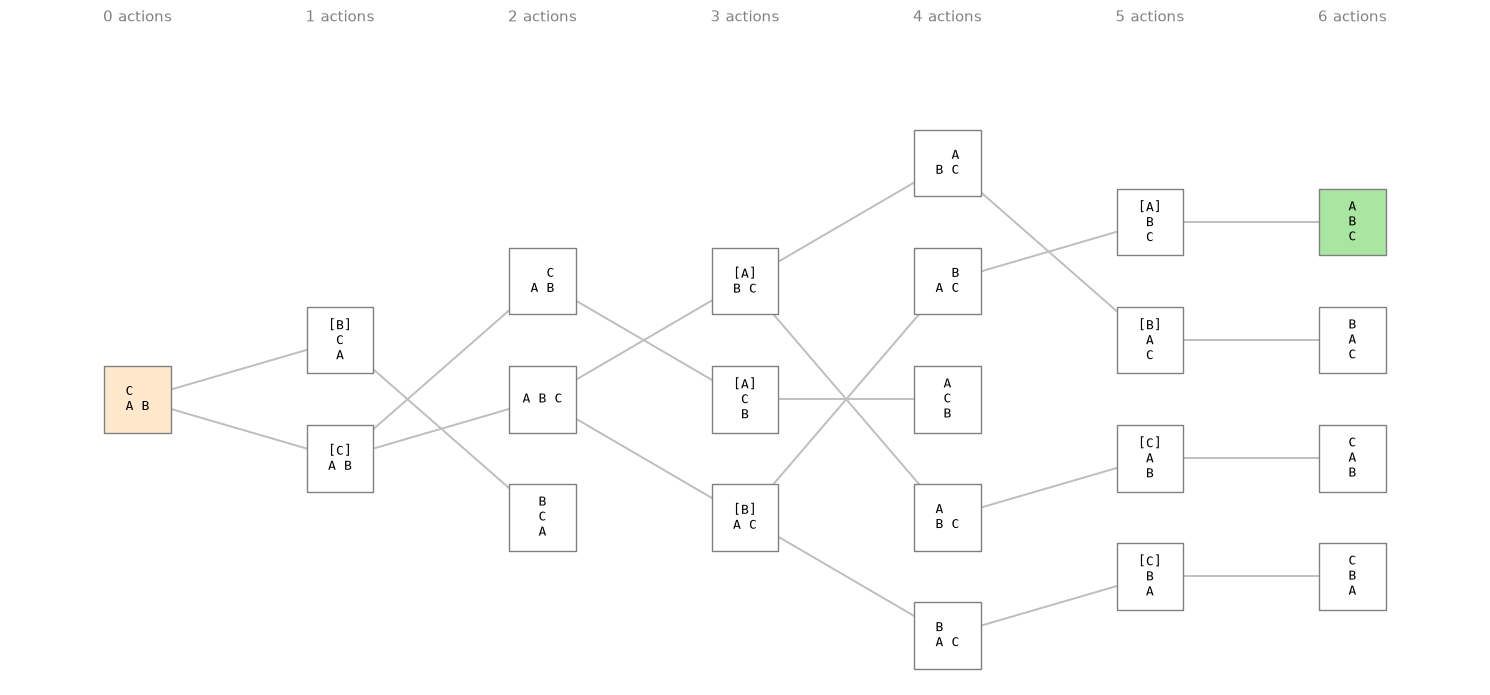

In [16]:
domain, problem, actions = load("blocks-domain.pddl", "blocks-sussman.pddl")
G = explore(problem.init, actions)
print(G.number_of_nodes(), "states,", G.number_of_edges(), "transitions")
draw_blocks(G, problem.init, problem.goal)

Columns are the fewest actions from the start. Read off the shortest plan to a green state.

## The workshop

In [17]:
domain, problem, actions = load("domain.pddl", "problem.pddl")
print(len(problem.objects), "objects,", len(domain.actions), "schemas,", len(actions), "grounded actions")
for name in successors(problem.init, actions):
    print(name)

6 objects, 9 schemas, 52 grounded actions
walk-between-rooms(lab, outdoors)
pick-up(cat, lab)
pick-up(dog, lab)
pick-up-tool(knife, lab)
pick-up-tool(dslr, lab)


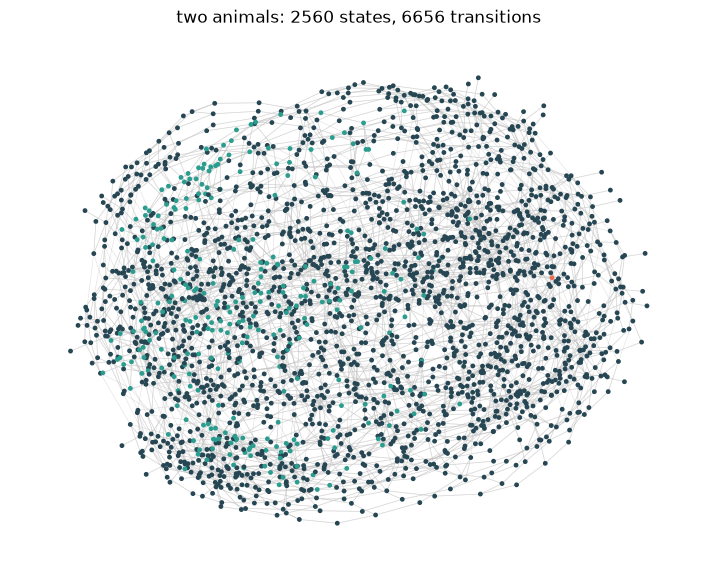

In [19]:
G = explore(problem.init, actions)
draw_cloud(G, problem.init, problem.goal, "two animals: ")   # the layout takes about 20 s

Two animals, two tools, two rooms: 2,560 states. Nothing to read any more; only a shape.

Same domain, more items: how fast does it grow?

In [20]:
for n in (1, 2, 3):
    problem = parse_problem(workshop_problem(n))
    actions = [g for a in domain.actions.values() for g in ground(a, problem.objects, domain.types)]
    G = explore(problem.init, actions)
    print(f"{n} items: {len(actions):3d} grounded actions  {G.number_of_nodes():7,d} states")

1 items:  28 grounded actions      160 states
2 items:  52 grounded actions    2,560 states
3 items:  84 grounded actions   57,344 states


Four items: 1.6 million states, 2 GB. Ten: about 10¹³.

The graph exists; nobody can build it. Week 3: find a plan without building it.